# From flipping coins to rolling dice

### A brief intro to the Dirichlet and Multinomial distributions

In previous lectures, we have looked at the bias of coins. This has many practical applications as very often we are interested in determining binary phenomena, e.g., knowing whether or not a medicine is effective, or a baseball player bats than other one, etc.

However, what if we would like to estimate the probabilities of non-binary phenomena? For instance, what if we would like to estimate the probability of obtaining the outcome of a die?

An option could be to use several random variables (e.g., 6 beta distributions) each modeling the probability of getting of outcome of the die. **Why isn't this a good approach?**


The outcome of a die are not independent of each other. If I get a 2 then I know that I could not have gotten 1,3,4,5,6. Using several independent random variables does not enforce this dependency. To tackle this problem, we need a vector of random variables whose elements *always* add up to one. One such a distribution is the _Dirichlet distribution_.

### Dirichlet distribution

The [Dirichlet distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) is _continuous multivariate_ distribution. It takes as a parameter a vector α of positive reals. This distribution is also known as multivariate beta distribution. The support of the distribution is a vector of reals in the interval $(0,1)$. The size of the vector equals the size of $\vec{\alpha}$. Importantly for our problem, is that the sum of each of the elements of the vector always equals 1. The figure below shows the pdf of the distribution for different $\vec{\alpha}$ parameters of size.

<img src="./Dirichlet.png" style="width: 500px">


### Multinomial distribution

As for flipping coins, now we need a likelihood function determining the probability of the outcomes of a die. As you might have noticed, the binomial distribution cannot be used in this setting, as it concerns binary outcomes. To address this scenario we look at a generalization of the binomial distribution: the _multinomial distribution_.

The [Multinomial distribution](https://en.wikipedia.org/wiki/Multinomial_distribution) models the probability of success of $n$ independent trials for $k$ different outcomes. For instance, applied to our die problem, it models the probability of getting any of the $6$ different outcomes (resulting from following the die) given that we have rolled the die $n$ times. This distribution requires that the $k$ outcomes are mutually exclusive; i.e., only one outcome can result from each trial.

## Example in PyMC

In what follows, we show an example in PyMC3 of using the Dirichlet and Multinomial distributions in the rolling die problem. **Our goal is to estimate the probability of each of the outcomes of the die**. (This might be useful in a casino to determine whether the die is ricked.)

As usual, we start importing the required libraries.

In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

We define the dataset resulting from rolling the die a number of times. We use this dataset to estimate the bias of the die.

In [2]:
# data
# N_1 = N_2 = N_3 = N_4 = N_5 = N_6 = 20 # only for presenation

N_1 = 30
N_2 = 5
N_3 = 15
N_4 = 35
N_5 = 25
N_6 = 10

data=[N_1, N_2, N_3, N_4, N_5, N_6]
N=sum(data)

The probabilistic model defines a Dirichlet prior with $\alpha = \langle 1,1,1,1,1,1 \rangle$ (uniform). The vector has size 6; one for each of the outcomes of the die. We use a multinomial distribution as likelihood function. Additionally, we add a deterministic node to compute the cumulative probability of the outcomes 1-3: in a fair die, it should be 0.5.

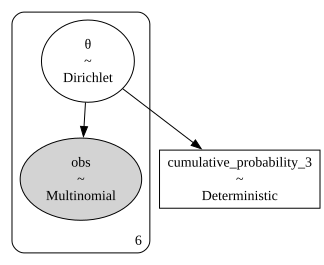

In [4]:
with pm.Model() as dirichlet_multinomial_intro:
    # prior
    θ = pm.Dirichlet('θ', a=np.array([1,1,1,1,1,1]))
    
    # likelihood
    pm.Multinomial('obs', n=N, p=θ, observed=data)
    
    # distributions of (possible) interest
    pm.Deterministic('cumulative_probability_3',θ[0]+θ[1]+θ[2])

# plotting the model for presentation
pm.model_to_graphviz(dirichlet_multinomial_intro)

In [5]:
with dirichlet_multinomial_intro:
    # sampling
    trace=pm.sample(10000,tune=5000,return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 5_000 tune and 10_000 draw iterations (20_000 + 40_000 draws total) took 62 seconds.


Finally, we plot the distributions and look at the diagnoses.

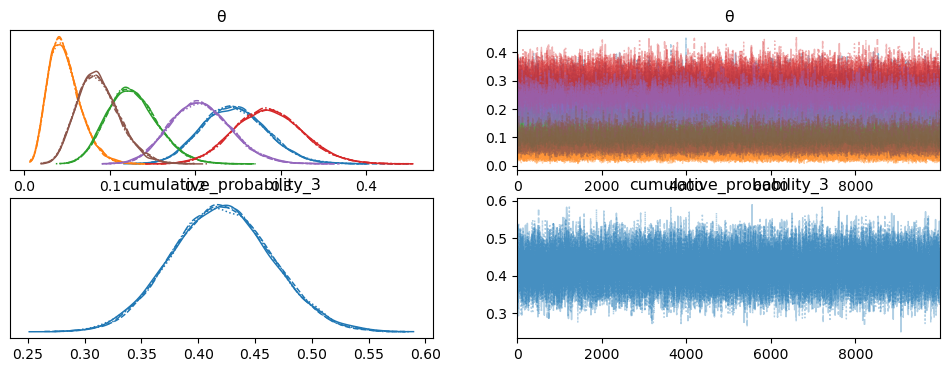

In [6]:
az.plot_trace(trace)
plt.show()

In [7]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
θ[0],0.246,0.038,0.178,0.320,0.0,0.0,40899.0,28721.0,1.0
θ[1],0.048,0.019,0.015,0.083,0.0,0.0,32172.0,23831.0,1.0
θ[2],0.127,0.030,0.072,0.182,0.0,0.0,38739.0,25830.0,1.0
θ[3],0.286,0.040,0.213,0.364,0.0,0.0,42387.0,27667.0,1.0
θ[4],0.206,0.036,0.141,0.274,0.0,0.0,36089.0,26775.0,1.0
θ[5],0.087,0.025,0.044,0.135,0.0,0.0,46687.0,31094.0,1.0
cumulative_probability_3,0.421,0.044,0.340,0.504,0.0,0.0,40994.0,31155.0,1.0
